## Tool Creation and usage with Chatbot

I will use **Travily API** for a tool calling and also create some othe custom tools. So our State Graph structure will be something as below: -

1. Here we will have a **tool_calling_llm** in which we will have **tools** and **LLM**. This is our **Node**.
2. For tools, we will have one **Tavily Search Tool** and some **Custom Tools** like **Multiplication Tool**, **Addition Tool** etc. These tools will be residing in **Tool-Node**.
3. Finally we'll bind the tools with our LLM for specific actions and each tools will have **Doc String** for mentioning the tool purpose.



In [38]:
import os
from dotenv import load_dotenv
load_dotenv()
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch


#Defining LLM
llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash") #released on 22nd July 2026

toolTavily = TavilySearch(max_results=2)


#Defining custom tool
def addition(a: int, b:int) -> int:
    """Add number a and b
    
    Args:
        a (int) is the first integer
        b (int) is the second integer
    
    Returns: 
        int output int
    """
    return a+b
    
tools = [toolTavily, addition]

# Now I'll bind the LLM with the above tools
lll_binded_tools = llm.bind_tools(tools)







In [39]:
# Defining Class for message output with Reducer and Annotator
class MsgFormat(TypedDict):
    messages: Annotated[list, add_messages]

Implementing stategraph for the Tools using ToolNode. The diagram depicts my Nodes and Edges. 

- Two Nodes are there: `tool_call_llm` and `tools`
- Three Edges are there: `START-Egde`, `Two Conditional Edges`

![StateGraph-Nodes&Edges](../assets/conditionalTool.png)

In [33]:

# Node Definition, here we will have two nodes
#1. Tool calling LLM
def tool_calling_llm(MsgFormat: MsgFormat):
    return {"messages": [lll_binded_tools.invoke(MsgFormat["messages"])]}

#2. Custom Tool of Addition is second node

# Assign StateGraph with msg reducer
graph_builder = StateGraph(MsgFormat)

# Draw the graph, two nodes, two edges
graph_builder.add_edge(START, "tool_call_llm")
graph_builder.add_node("tool_call_llm", tool_calling_llm)
graph_builder.add_conditional_edges(
    "tool_call_llm",
    #Cond.1: The LLM might call tool
    #cond.2: The LLM might does not call tool and go to END.path=
    
    tools_condition #Condition for edge where to go according to user's question
)
graph_builder.add_node("tools", ToolNode(tools)) #The first name "tools" shoul match with the name "tool"  as we assigned at the top.
graph_builder.add_edge("tools", END)

compiled_graph = graph_builder.compile()

In [1]:
# Visualize the Graph
from IPython.display import Image, display

try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

Getting Recent news from the LLM using the Travily tool call

In [ ]:
llm_response = compiled_graph.invoke({"messages": "At what point does NIFTY closed today?"})

#llm_response

Formatting the response

In [ ]:
for msg in llm_response["messages"]:
    msg.pretty_print()
     

Asking another message to check whether Custom Tool call is made

In [ ]:
llm_response = compiled_graph.invoke({"messages": "What is 2 + 101?"})

for messg in llm_response["messages"]:
    messg.pretty_print()

Giving complex question like two assignemnts to check whether the LLM properly calls the tools or not. 

In [ ]:
llm_response = compiled_graph.invoke({"messages": "What is the AI news today and then do addition of 2 and 101?"})

for messg in llm_response["messages"]:
    messg.pretty_print()

Now for the last question I asked : `What is the AI news today and then do addition of 2 and 101?` has two parts - 
- AI news part
- Addition of 2 and 102

So in our last State Graph, the LLM can handle only one question at a single I/P as per our Node design. Once the LLM generates the first answer by calling Travily API, it goes to the END node and hence life-cycle ends there. It never takes the second question `addition of 2 and 101`. So it becomes dead-end.

To mitigate this issue we will do :
- Once the first question (I/P) is processed the output is send back to the LLM.
- The LLM will observe that Output response and `Reason` itself whether more toolcall is required for user I/P question or should it move to the END node.
- For our question, it should again call `addition` tool for addition.
- Again this output is send to the LLM (tool_calling_llm) Node and it then Observes and Reasons what to do next.
- Since there is nothing to do, it goes to the END node. 

So we need to rebuild our graph. We need an `EDGE` which will revert back to LLM tool calling node instead of going to the END node.

This `Agent Architecture` is called as **ReAct** Architecture. So **ReAct** consists of -
- **Act**
- **Observe**
- **Reason**

- **Act** - When user gives input, the LLM will be making a tool call, thus acting on the user input
- **Observe** - When the output of the Toolcall comes back to the LLM based on some user input, the LLM observes it. It will observe the output and make decision that whether it again need to make tool call or should it go the END.
- **Reason** - When the LLM is receiving the output then LLM is taking decision of what to do. This is **reasoning**.

So this rises **Agentic AI** and **Agent** comes into picture.


![Agent-Graph](../assets/AgentGraph.png)

In [ ]:

# ReAct Agent
#1. Tool calling LLM
def tool_calling_llm(MsgFormat: MsgFormat):
    return {"messages": [lll_binded_tools.invoke(MsgFormat["messages"])]}

#2. Custom Tool of Addition is second node

# Assign StateGraph with msg reducer
graph_builder = StateGraph(MsgFormat)

# Draw the graph, two nodes, two edges
graph_builder.add_edge(START, "tool_call_llm")
graph_builder.add_node("tool_call_llm", tool_calling_llm)
graph_builder.add_conditional_edges(
    "tool_call_llm",
    #Cond.1: The LLM might call tool
    #cond.2: The LLM might does not call tool and go to END.path=
    
    tools_condition #Condition for edge where to go according to user's question
)
graph_builder.add_node("tools", ToolNode(tools)) #The first name "tools" should match with the name "tool"  as we assigned at the top.
graph_builder.add_edge("tools", "tool_call_llm")

compiled_graph = graph_builder.compile()



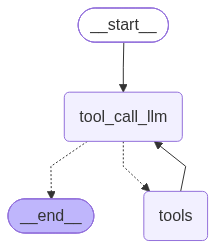

In [42]:
# Visualize the Graph
from IPython.display import Image, display

try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
llm_response = compiled_graph.invoke({"messages": "What is the current weather today in Balurghat, West Bengal and then do addition of 2 and 101?"})

for messg in llm_response["messages"]:
    messg.pretty_print()

## Adding Memory to keep conversation

For chat history we need persistent memory for keeping previous chat messages in memory. That introduces **adding memory**. 

In [45]:
# Memorysaver needs to be imported from Langraph >> checkpoint >> memory
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() #Assigning MemorySaver object in memory variable

def tool_calling_llm(MsgFormat: MsgFormat):
    return {"messages": [lll_binded_tools.invoke(MsgFormat["messages"])]}

graph_builder = StateGraph(MsgFormat)

# Draw the graph, two nodes, two edges
graph_builder.add_edge(START, "tool_call_llm")
graph_builder.add_node("tool_call_llm", tool_calling_llm)
graph_builder.add_conditional_edges(
    "tool_call_llm",
    tools_condition 
)
graph_builder.add_node("tools", ToolNode(tools)) 
graph_builder.add_edge("tools", "tool_call_llm")

Now while compiling the Graph, we will add a parameter of memory into it.

In [46]:
compiled_graph = graph_builder.compile(checkpointer=memory)

Now we need to create a thread for passing it as congig to the LLM for mainitaing proper chathistory and session.

In [47]:
config = {
    "configurable": {
        "thread_id": "user1"
    }
}

Sending my name to remember.

In [ ]:
response = compiled_graph.invoke({"messages": "Hi, my name is Pankaj."}, config)

print(response["messages"][-1].content)

Checking whether it remembers my name. This is persisting memory.

In [ ]:
response = compiled_graph.invoke({"messages": "Hey what is my name?"}, config)
print(response["messages"][-1].content)

## Streaming the response

Two types of **Streaming** method:
- `.stream()`
- `.astream()`

They are **sync** and **async** method in streaming. There are also `two additional parameters` used in streaming mode. They are:
- **Values** - This streams the full state of the graph after each node is called.
- **Updates** - This streams updates to the state of the graph after each node is called.

For this I will create a new simple state graph with a single Node without any tool calling for now.

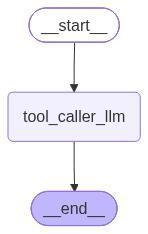

In [64]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() #Assigning MemorySaver object in memory variable

def llm_tool_caller(MsgFormat: MsgFormat):
    return {"messages": [llm.invoke(MsgFormat["messages"])]}

graph_builder = StateGraph(MsgFormat)

# Draw the graph, two nodes, two edges
graph_builder.add_edge(START, "tool_caller_llm")
graph_builder.add_node("tool_caller_llm", llm_tool_caller)
graph_builder.add_edge("tool_caller_llm", END)

# Visualize the Graph
from IPython.display import Image, display

try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [53]:
compiled_graph = graph_builder.compile(checkpointer=memory)

config = {
    "configurable": {
        "thread_id": "stream1"
    }
}

Case1: When the `stream_mode` is `update`. Here only the final value it getting updated in the `messages` object.

In [ ]:
response = compiled_graph.stream({"messages": "Hi, my name is Pankaj."}, config, stream_mode="updates") #Need to pass config and stream_mode here

for msg in response:
    print(msg)

Case2: When the `stream_mode` is `value`. So one thing notice here is that, the `messages` is got appended with the new messages which is acting like `reducer` (`from langgraph.graph.message import add_messages`).

### Difference between stream_mode = Values and stream_mode = Updates

- For `Values`, we can see all the **HumanMessages** and **AI messages** as a proper chat history of all the messages. 
- For `Updates`, it will display only the **AIMessage** and which is last updated message.

In [ ]:
response = compiled_graph.stream({"messages": "I am planning to develop Education App based on Agentic AI."}, config, stream_mode="values") #Need to pass config and stream_mode here

for msg in response:
    print(msg)

Streaming using `astream_events` mode. It logs very detailed information of each and every **events** and is useful in debugging.

In [ ]:
compiled_graph = graph_builder.compile(checkpointer=memory)

config = {
    "configurable": {
        "thread_id": "astream_1"
    }
}

response = compiled_graph.astream_events({"messages": "I am planning to develop Education App based on Agentic AI."}, config, version="v1") #Need to pass config and stream_mode here

async for msg in response: #Since aync method, aync keyword need to be used.
    print(msg)

{'event': 'on_chain_start', 'run_id': '019f8a44-78f9-7b00-a6c3-98679b842efa', 'name': 'LangGraph', 'tags': [], 'metadata': {}, 'data': {'input': {'messages': 'I am planning to develop Education App based on Agentic AI.'}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'tool_caller_llm', 'run_id': '019f8a44-78fd-7a41-8ffe-02c74514405f', 'tags': ['graph:step:7'], 'metadata': {'thread_id': 'astream_1', 'ls_integration': 'langgraph', 'langgraph_step': 7, 'langgraph_node': 'tool_caller_llm', 'langgraph_triggers': ('branch:to:tool_caller_llm',), 'langgraph_path': ('__pregel_pull', 'tool_caller_llm'), 'langgraph_checkpoint_ns': 'tool_caller_llm:8bcd1ba7-4f7a-80c6-2cfb-bfbfabc2d3ff'}, 'data': {'input': {'messages': [HumanMessage(content='I am planning to develop Education App based on Agentic AI.', additional_kwargs={}, response_metadata={}, id='eb00a21e-050f-46b8-9765-c2c4ee9a5e54'), AIMessage(content=[{'type': 'text', 'text': 'Developing an educational app powered by **Agentic AI** i